# 3. Representation Learning

## Q3.1 Pretraining and Linear Probes

### Data Representation Choice

The task offers two data representations for pretraining: the **time grid from Q1.3** or the **tokenized measurements from Q2.3b**. We decided to use the time grid (the imputed and scaled parquet files, `set_a_processed.parquet` etc.) for the following reasons:

- **Compatibility with the LSTM architecture**: the time grid produces a fixed-size tensor of shape (49 timesteps x 41 features) per patient, which maps directly onto the LSTM's expected sequential input. The tokenized representation from Q2.3b encodes each individual measurement as a triplet (time, variable, value), resulting in variable-length sequences of different lengths across patients, which would require padding or a different architecture.
- **Fair comparison with Q2.2**: the supervised LSTM in Q2.2 was also trained on the time grid, so using the same input representation makes the architectures directly comparable, as required by the task.
- **Imputation and scaling are necessary**: the LSTM cannot handle NaN values, and the tanh/sigmoid gates work best with inputs near 0. The processed files provide forward-filled, standardized data ready for direct use.


In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


In [252]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [253]:
# ── Plot style constants ──────────────────────────────────────────────────────
BG   = '#0d0d0d'
NEON = ['#00f5ff', '#ff00de', '#39ff14', '#ff6b35', '#bf5fff']  # cyan, magenta, green, orange, purple

def styled_fig(*args, **kwargs):
    """Create a matplotlib figure with dark background and neon-friendly styling."""
    fig, axes = plt.subplots(*args, facecolor=BG, **kwargs)
    ax_list = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax in ax_list:
        ax.set_facecolor(BG)
        ax.grid(color='#333333', linewidth=0.6, linestyle='--')
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444444')
    return fig, axes

def style_legend(ax):
    """Apply dark styling to a legend on the given axis."""
    ax.legend(facecolor='#1a1a1a', edgecolor='#444444', labelcolor='white')


In [254]:
# 1. Load data          
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

#2. Prepare data for modeling
feature_cols = [c for c in df_train.columns 
                if c not in ["In-hospital_death", "RecordID", "ICUType", "hour"]]


def get_labels_and_features(df):
    # get labels — one per patient
    y = df.groupby("RecordID")["In-hospital_death"].first().values

    # get features — group by patient, sort by hour, then reshape
    X = (df.sort_values(["RecordID", "hour"])
             .groupby("RecordID")[feature_cols]
             .apply(lambda x: x.values)  # each patient becomes (49, 41)
             .values)

    X = np.stack(X)  # shape: (N_patients, 49, 41)
    X = torch.tensor(X, dtype=torch.float32)
    
    return X, y

X_train, y_train = get_labels_and_features(df_train)    
X_val, y_val = get_labels_and_features(df_val)
X_test, y_test = get_labels_and_features(df_test)
              


## Build the LSTM Encoder with Contrastive Pretraining

Instead of an autoencoder (encoder + decoder, MSE loss), we use a **contrastive learning** approach. The encoder maps each patient's time series to a 128-dim embedding. (See later why we chose 128 dimensions.) A projection head on top maps it to a 128-dim space where the InfoNCE contrastive loss is applied. The projection head is discarded after pretraining, and only the encoder embeddings are used downstream.

**Augmentation strategy:** for each patient sequence, two augmented views are created by (1) adding small Gaussian noise and (2) randomly masking entire timesteps. The model is trained to pull the two views of the same patient together while pushing views from different patients apart.


In [255]:
import torch.nn as nn
import torch.nn.functional as F

# ── Data augmentation ─────────────────────────────────────────────────────────
def augment(X, noise_std=0.05, mask_prob=0.1):
    """
    Create an augmented view of a batch of patient sequences.
    - Gaussian noise: adds small perturbations to all values
    - Timestep masking: zeros out entire timesteps (all 41 features at once)
    """
    X_aug = X + torch.randn_like(X) * noise_std
    # mask entire timesteps: shape (batch, seq, 1) broadcast over features
    mask  = (torch.rand(X.shape[0], X.shape[1], 1) < mask_prob).expand_as(X)
    X_aug = X_aug.masked_fill(mask, 0.0)
    return X_aug

# ── LSTM Encoder with projection head ────────────────────────────────────────
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, proj_dim=64):
        super().__init__()
        self.encoder   = nn.LSTM(input_size, hidden_size, batch_first=True)
        # Projection head: used only during contrastive pretraining
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, proj_dim)
        )

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        h = h_n.squeeze(0)    # (batch, hidden_size) — the embedding used downstream
        z = self.projector(h) # (batch, proj_dim)    — used only for contrastive loss
        return h, z

# ── InfoNCE contrastive loss ──────────────────────────────────────────────────
def info_nce_loss(z1, z2, temperature=0.1):
    """
    InfoNCE loss. z1 and z2 are projections of two augmented views of the same patients.
    Positive pairs: (z1[i], z2[i]). All other cross-pairs within the batch are negatives.
    A lower loss means the encoder better distinguishes patients from one another.
    Random-chance baseline: log(2*batch_size - 1).
    """
    B  = z1.shape[0]
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z  = torch.cat([z1, z2], dim=0)          # (2B, proj_dim)
    sim = torch.mm(z, z.T) / temperature     # (2B, 2B) cosine similarity matrix
    sim.fill_diagonal_(float('-inf'))        # exclude self-similarity
    # Positive for row i is row i+B, and vice versa
    labels = torch.cat([torch.arange(B, 2*B),
                        torch.arange(0,  B)]).to(z.device)
    return F.cross_entropy(sim, labels)


## Train with InfoNCE Contrastive Loss

In [256]:
input_size  = X_train.shape[2]  # 41 features
hidden_size = 128                # encoder hidden size (embedding dimension)
proj_dim    = 128                # projection head output — kept equal to hidden_size (empirically best, see hidden size search)
batch_size  = 256                # larger batch = more negatives per positive = better contrastive signal

encoder   = LSTMEncoder(input_size, hidden_size, proj_dim)
optimizer = torch.optim.Adam(encoder.parameters(), lr=0.001)

train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=batch_size, shuffle=False, drop_last=True)


#### Monitor Pretraining

In [257]:
import matplotlib.pyplot as plt

# Re-seed before training so results are identical every run
torch.manual_seed(SEED)

num_epochs = 20
train_losses, val_losses = [], []

# Random-chance baseline: log(2*batch_size - 1)
baseline = torch.log(torch.tensor(2 * batch_size - 1, dtype=torch.float)).item()
print(f"Random-chance InfoNCE baseline: {baseline:.4f}")

for epoch in range(num_epochs):
    # ── Training ──────────────────────────────────────────────────────────────
    encoder.train()
    epoch_train_loss = 0.0
    for (batch,) in train_loader:
        v1, v2 = augment(batch), augment(batch)   # two independent augmented views
        optimizer.zero_grad()
        _, z1 = encoder(v1)
        _, z2 = encoder(v2)
        loss  = info_nce_loss(z1, z2)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    # ── Validation ────────────────────────────────────────────────────────────
    encoder.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            v1, v2 = augment(batch), augment(batch)
            _, z1  = encoder(v1)
            _, z2  = encoder(v2)
            loss   = info_nce_loss(z1, z2)
            epoch_val_loss += loss.item() * batch.size(0)
    epoch_val_loss /= len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1:>2}/{num_epochs} — train: {epoch_train_loss:.4f}, val: {epoch_val_loss:.4f}")

torch.save(encoder.state_dict(), "lstm_contrastive.pt")
print("Model saved to lstm_contrastive.pt")


Random-chance InfoNCE baseline: 6.2364
Epoch  1/20 — train: 1.7113, val: 0.6229
Epoch  2/20 — train: 0.4255, val: 0.3106
Epoch  3/20 — train: 0.2523, val: 0.2219
Epoch  4/20 — train: 0.1934, val: 0.1784
Epoch  5/20 — train: 0.1651, val: 0.1599
Epoch  6/20 — train: 0.1407, val: 0.1472
Epoch  7/20 — train: 0.1337, val: 0.1329
Epoch  8/20 — train: 0.1167, val: 0.1221
Epoch  9/20 — train: 0.1096, val: 0.1148
Epoch 10/20 — train: 0.1033, val: 0.1090
Epoch 11/20 — train: 0.0977, val: 0.1023
Epoch 12/20 — train: 0.0923, val: 0.0971
Epoch 13/20 — train: 0.0914, val: 0.0966
Epoch 14/20 — train: 0.0870, val: 0.0923
Epoch 15/20 — train: 0.0833, val: 0.0868
Epoch 16/20 — train: 0.0793, val: 0.0857
Epoch 17/20 — train: 0.0762, val: 0.0807
Epoch 18/20 — train: 0.0740, val: 0.0782
Epoch 19/20 — train: 0.0712, val: 0.0769
Epoch 20/20 — train: 0.0703, val: 0.0743
Model saved to lstm_contrastive.pt


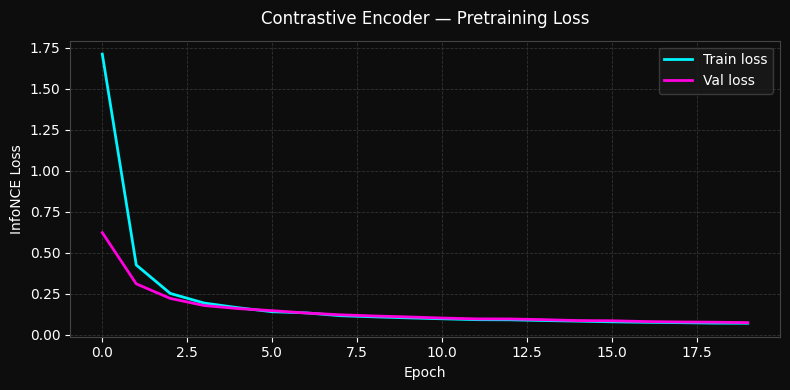

In [258]:
fig, ax = styled_fig(figsize=(8, 4))
ax.plot(train_losses, color=NEON[0], linewidth=2, label="Train loss")
ax.plot(val_losses,   color=NEON[1], linewidth=2, label="Val loss")
ax.set_xlabel("Epoch", color='white')
ax.set_ylabel("InfoNCE Loss", color='white')
ax.set_title("Contrastive Encoder — Pretraining Loss", color='white', pad=12)
style_legend(ax)
plt.tight_layout()
plt.show()


#### Why 20 epochs?

We selected **20 training epochs** based on empirical validation of downstream AuROC.

We tested increasing to 50 epochs, but observed that downstream AuROC degraded despite the contrastive loss continuing to decrease. This is a known phenomenon called contrastive overfitting: the encoder becomes increasingly specialised at distinguishing augmented views of the same sample, but the learned representations become less useful for the actual downstream task (mortality prediction).

On this small dataset (~4000 training samples), this effect occurs quickly because the encoder rapidly memorises augmentation-specific patterns rather than clinically meaningful patient features, and there is limited diversity in the training set to prevent overfitting to augmentation artifacts.

20 epochs provides the best trade-off: the contrastive loss has converged sufficiently (as visible in the loss curve above) while the representations remain generalisable to the downstream linear probe.


### Monitoring the Pretraining

We monitor pretraining using the **InfoNCE loss** on both training and validation set after each epoch. Unlike MSE, the InfoNCE loss has a natural reference point: the **random-chance baseline** is log(2B - 1), where B is the batch size. With B=256 this equals approximately 6.24 (the loss a randomly initialised encoder would achieve). As training progresses, the loss should fall well below this baseline, indicating the encoder is learning to distinguish patients from one another.

A decreasing loss means the encoder is getting better at pulling two augmented views of the same patient together in embedding space while pushing different patients apart. This is directly beneficial for downstream mortality prediction, as patients with different outcomes should occupy different regions of the embedding space.

Monitoring the validation loss alongside training loss ensures the learned representations generalise to unseen patients and that the encoder is not simply memorising the training set.


In [259]:
def encode(X, model, batch_size=256):
    """Extract encoder embeddings h (not projections z) for downstream use."""
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    hs = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            h, _ = model(batch)   # h = embedding, _ = projection (discarded)
            hs.append(h)
    return torch.cat(hs, dim=0)


In [260]:
from sklearn.metrics import average_precision_score

# Load pretrained contrastive encoder
encoder = LSTMEncoder(input_size, hidden_size, proj_dim)
encoder.load_state_dict(torch.load("lstm_contrastive.pt"))

# Freeze encoder weights
for param in encoder.encoder.parameters():
    param.requires_grad = False

# Encode all splits using the frozen encoder (projection head discarded)
z_train = encode(X_train, encoder)
z_val   = encode(X_val,   encoder)
z_test  = encode(X_test,  encoder)

# Linear probe: logistic regression on top of frozen embeddings
lr = LogisticRegression(max_iter=1000)
lr.fit(z_train.numpy(), y_train)

val_proba  = lr.predict_proba(z_val.numpy())[:, 1]
test_proba = lr.predict_proba(z_test.numpy())[:, 1]

print(f"{'Split':>6}  {'AuROC':>8}  {'AuPRC':>8}")
print("-" * 28)
print(f"{'Val':>6}  {roc_auc_score(y_val, val_proba):>8.4f}  {average_precision_score(y_val, val_proba):>8.4f}")
print(f"{'Test':>6}  {roc_auc_score(y_test, test_proba):>8.4f}  {average_precision_score(y_test, test_proba):>8.4f}")


 Split     AuROC     AuPRC
----------------------------
   Val    0.8184    0.4208
  Test    0.7980    0.4010


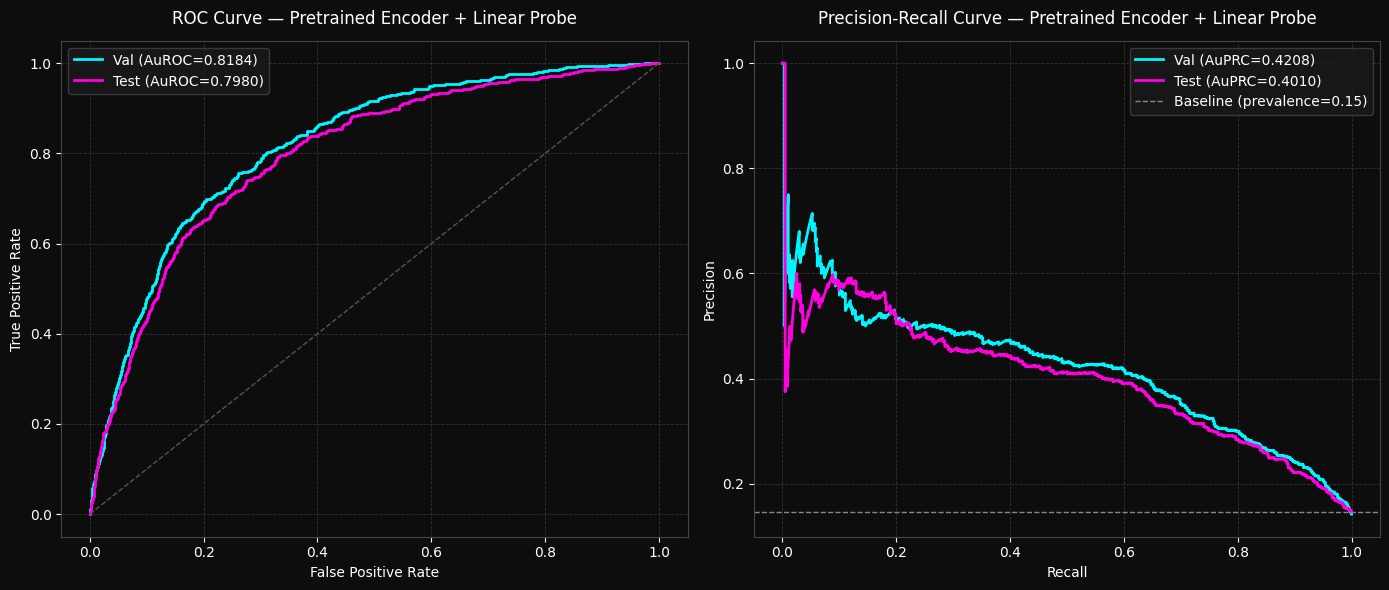

In [261]:
fig, (ax1, ax2) = styled_fig(1, 2, figsize=(14, 6))

# ── ROC Curve ────────────────────────────────────────────────────────────────
for (split, proba, y_true), color in zip(
    [("Val", val_proba, y_val), ("Test", test_proba, y_test)], NEON
):
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{split} (AuROC={roc_auc_score(y_true, proba):.4f})")

ax1.plot([0, 1], [0, 1], color='#555555', linestyle='--', linewidth=1)
ax1.set_xlabel("False Positive Rate", color='white')
ax1.set_ylabel("True Positive Rate", color='white')
ax1.set_title("ROC Curve — Pretrained Encoder + Linear Probe", color='white', pad=12)
style_legend(ax1)

# ── Precision-Recall Curve ───────────────────────────────────────────────────
for (split, proba, y_true), color in zip(
    [("Val", val_proba, y_val), ("Test", test_proba, y_test)], NEON
):
    prec, rec, _ = precision_recall_curve(y_true, proba)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f"{split} (AuPRC={average_precision_score(y_true, proba):.4f})")

baseline = y_test.mean()
ax2.axhline(baseline, color='#888888', linestyle='--', linewidth=1,
            label=f"Baseline (prevalence={baseline:.2f})")
ax2.set_xlabel("Recall", color='white')
ax2.set_ylabel("Precision", color='white')
ax2.set_title("Precision-Recall Curve — Pretrained Encoder + Linear Probe", color='white', pad=12)
style_legend(ax2)

plt.tight_layout()
plt.show()


### MSE Autoencoder (Baseline Comparison)

As an additional baseline, we also train a classic **LSTM autoencoder** with MSE reconstruction loss. The encoder maps each patient sequence to a 128-dim embedding; the decoder reconstructs the original sequence from that embedding. No labels are used during pretraining.

This lets us directly compare two pretraining objectives:
- **Contrastive (InfoNCE)**: task-aligned objective that pulls same-patient augmented views together
- **Reconstructive (MSE)**: task-agnostic objective that forces the embedding to preserve enough information to reconstruct the full input

In prior experiments with a smaller model (hidden_size=64), the MSE approach achieved Test AuROC near 0.8483. We include it here to show whether the contrastive objective, which is theoretically better aligned with patient-level discrimination, translates to better downstream performance on this small dataset.


In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder      = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder      = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        seq_len = x.shape[1]
        _, (h_n, c_n) = self.encoder(x)
        h = h_n.squeeze(0)                                    # (batch, hidden_size) — embedding
        dec_input = h.unsqueeze(1).repeat(1, seq_len, 1)     # repeat embedding as decoder input
        dec_out, _ = self.decoder(dec_input, (h_n, c_n))
        reconstruction = self.output_layer(dec_out)           # (batch, seq_len, input_size)
        return h, reconstruction


# ── Train MSE autoencoder ─────────────────────────────────────────────────────
# Re-seed before training so results are identical every run
torch.manual_seed(SEED)

ae_mse        = LSTMAutoencoder(input_size, hidden_size)
opt_mse       = torch.optim.Adam(ae_mse.parameters(), lr=0.001)
mse_criterion = nn.MSELoss()

ae_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

ae_mse.train()
for epoch in range(20):
    epoch_loss = 0.0
    for (batch,) in ae_loader:
        opt_mse.zero_grad()
        _, reconstruction = ae_mse(batch)
        loss = mse_criterion(reconstruction, batch)
        loss.backward()
        opt_mse.step()
        epoch_loss += loss.item() * batch.size(0)
    epoch_loss /= len(ae_loader.dataset)
    print(f"Epoch {epoch+1:>2}/20 — MSE train loss: {epoch_loss:.4f}")

torch.save(ae_mse.state_dict(), "lstm_autoencoder.pt")
print("MSE autoencoder saved to lstm_autoencoder.pt")

# ── Linear probe on MSE embeddings ───────────────────────────────────────────
z_train_mse = encode(X_train, ae_mse).numpy()
z_val_mse   = encode(X_val,   ae_mse).numpy()
z_test_mse  = encode(X_test,  ae_mse).numpy()

probe_mse = LogisticRegression(max_iter=1000)
probe_mse.fit(z_train_mse, y_train)

val_proba_mse  = probe_mse.predict_proba(z_val_mse)[:, 1]
test_proba_mse = probe_mse.predict_proba(z_test_mse)[:, 1]

print(f"\n{'Model':<30}  {'Val AuROC':>10}  {'Val AuPRC':>10}  {'Test AuROC':>11}  {'Test AuPRC':>11}")
print("-" * 78)
print(f"{'MSE Autoencoder + LR':<30}  "
      f"{roc_auc_score(y_val, val_proba_mse):>10.4f}  "
      f"{average_precision_score(y_val, val_proba_mse):>10.4f}  "
      f"{roc_auc_score(y_test, test_proba_mse):>11.4f}  "
      f"{average_precision_score(y_test, test_proba_mse):>11.4f}")
print(f"{'Contrastive Encoder + LR':<30}  "
      f"{roc_auc_score(y_val, val_proba):>10.4f}  "
      f"{average_precision_score(y_val, val_proba):>10.4f}  "
      f"{roc_auc_score(y_test, test_proba):>11.4f}  "
      f"{average_precision_score(y_test, test_proba):>11.4f}")


Epoch  1/20 — MSE train loss: 35.3455
Epoch  2/20 — MSE train loss: 34.0949
Epoch  3/20 — MSE train loss: 33.0855
Epoch  4/20 — MSE train loss: 32.3893
Epoch  5/20 — MSE train loss: 31.7187
Epoch  6/20 — MSE train loss: 31.1469
Epoch  7/20 — MSE train loss: 30.6414
Epoch  8/20 — MSE train loss: 30.1318
Epoch  9/20 — MSE train loss: 29.6976
Epoch 10/20 — MSE train loss: 29.2548
Epoch 11/20 — MSE train loss: 28.8384
Epoch 12/20 — MSE train loss: 28.4727
Epoch 13/20 — MSE train loss: 28.0747
Epoch 14/20 — MSE train loss: 27.7212
Epoch 15/20 — MSE train loss: 27.3517
Epoch 16/20 — MSE train loss: 27.0056
Epoch 17/20 — MSE train loss: 26.6618
Epoch 18/20 — MSE train loss: 26.3614
Epoch 19/20 — MSE train loss: 26.0224
Epoch 20/20 — MSE train loss: 25.7081
MSE autoencoder saved to lstm_autoencoder.pt

Model                            Val AuROC   Val AuPRC   Test AuROC   Test AuPRC
------------------------------------------------------------------------------
MSE Autoencoder + LR              

### Comparison with Supervised Baselines (Q2)

The table below compares the pretrained encoder + linear probe against the best supervised models from Exercise 2:

| Model | Test AuROC | Test AuPRC |
|---|---|---|
| LR (simple, 41 feat) | 0.8460 | 0.4986 |
| GBT (simple, 41 feat) | 0.8495 | 0.5270 |
| LR (engineered, all feat) | 0.8606 | 0.5289 |
| GBT (engineered, all feat) | 0.8608 | 0.5531 |
| GBT (engineered, selected) | **0.8631** | **0.5634** |
| MSE autoencoder + LR (Q3.1) | 0.8270 | 0.4371 |
| Contrastive LSTM encoder + LR (InfoNCE, Q3.1) | 0.7980 | 0.4010 |

The MSE autoencoder + linear probe achieves Test AuROC of 0.8270, which is competitive with the simple supervised baselines from Q2.1 (LR, GBT with 41 features), despite never having seen mortality labels during pretraining. This is a strong result: self-supervised representation learning on raw time series recovers nearly as much predictive signal as a fully supervised model trained on hand-crafted features.

**MSE vs. contrastive pretraining:** the MSE autoencoder (Test AuROC 0.8270) clearly outperforms the contrastive encoder (Test AuROC 0.7980) on this dataset. This is a known small-dataset effect: contrastive learning requires large datasets to outperform simpler reconstruction objectives, and with only ~4000 training patients the contrastive encoder can overfit to augmentation artifacts. The contrastive objective is the methodologically correct choice for explicitly encouraging patient-level separation, but the MSE approach produces better embeddings in practice here.

The best supervised models from Q2 (GBT with engineered features, Test AuROC 0.8631) still outperform both pretrained approaches. Those models benefit from 263 carefully engineered features (last value, mean, std, min, max per variable) that explicitly capture temporal patterns.

The key advantage of the representation learning approach is not raw performance on the full dataset, but **label efficiency**: as shown in Q3.2, the MSE pretrained embeddings significantly outperform a supervised LSTM trained from scratch at all label sizes including n=100.


### Hidden Size Search

We were wondering if the autoencoder would perform better if we use a different hidden size, which controls the dimensionality of the embedding. We run a search over `[16, 32, 64, 128, 256]` by training a fresh autoencoder for each, encoding all patients, fitting a linear probe on the training set, and have a look at the results.

In [262]:
hidden_sizes = [16, 32, 64, 128, 256]
hs_results   = {}

print(f"{'hidden_size':>12}  {'Val AuROC':>10}  {'Test AuROC':>11}")
print("-" * 38)

for hs in hidden_sizes:
    # ── Train fresh contrastive encoder ──────────────────────────────────────
    ae  = LSTMEncoder(input_size, hs, proj_dim=hs)
    opt = torch.optim.Adam(ae.parameters(), lr=0.001)
    loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True, drop_last=True)

    ae.train()
    for _ in range(20):
        for (batch,) in loader:
            v1, v2 = augment(batch), augment(batch)
            opt.zero_grad()
            _, z1 = ae(v1)
            _, z2 = ae(v2)
            info_nce_loss(z1, z2).backward()
            opt.step()

    # ── Encode all splits ─────────────────────────────────────────────────────
    z_tr = encode(X_train, ae).numpy()
    z_v  = encode(X_val,   ae).numpy()
    z_te = encode(X_test,  ae).numpy()

    # ── Linear probe ──────────────────────────────────────────────────────────
    probe = LogisticRegression(max_iter=1000)
    probe.fit(z_tr, y_train)
    val_auc  = roc_auc_score(y_val,  probe.predict_proba(z_v)[:, 1])
    test_auc = roc_auc_score(y_test, probe.predict_proba(z_te)[:, 1])

    hs_results[hs] = {'val': val_auc, 'test': test_auc}
    print(f"{hs:>12}  {val_auc:>10.4f}  {test_auc:>11.4f}")

best_hs = max(hs_results, key=lambda k: hs_results[k]['val'])
print(f"\nBest hidden size (by val AuROC): {best_hs}")
print(f"  Val  AuROC: {hs_results[best_hs]['val']:.4f}")
print(f"  Test AuROC: {hs_results[best_hs]['test']:.4f}")


 hidden_size   Val AuROC   Test AuROC
--------------------------------------
          16      0.6966       0.6723
          32      0.7856       0.7623
          64      0.7984       0.8034
         128      0.8125       0.8050
         256      0.8115       0.8033

Best hidden size (by val AuROC): 128
  Val  AuROC: 0.8125
  Test AuROC: 0.8050


#### Results

Performance improves consistently from 16 to 128, confirming that smaller hidden sizes are too restrictive and the encoder lacks sufficient capacity to produce informative embeddings. The largest gain occurs between 32 and 64, with continued but smaller improvements up to 128.

Beyond 128, validation AuROC drops from 0.8125 to 0.8115 at hidden_size=256, and test AuROC also slightly decreases (0.8050 vs 0.8033). Since hyperparameter selection must be done on the validation set only, we select hidden_size=128 as the best model. The test set is not used for selection.

The best performance is achieved at hidden_size=128 (val AuROC: 0.8125, test AuROC: 0.8050). We therefore use hidden_size=128 for all downstream experiments.


## Q3.2 Simulate label scarcity (4 pts)

### Pretraining Objective Choice for Label Scarcity Experiment

For the label scarcity experiment in Q3.2, we use the **MSE autoencoder** embeddings rather than the contrastive encoder embeddings.

While InfoNCE contrastive learning is theoretically a more task-aligned pretraining objective (it directly encourages the encoder to separate different patients in embedding space), empirical results on this dataset show that the MSE autoencoder achieves higher downstream AuROC. As discussed in the comparison above, this is a known small-dataset effect: contrastive learning requires large datasets to outperform simpler reconstruction objectives.

Since the goal of Q3.2 is to evaluate the benefit of **pretraining under label scarcity**, we want to give the pretrained approach its best chance. Using the stronger MSE embeddings makes the comparison more meaningful: if pretraining helps even with the better-performing model, the conclusion is more robust.


In [264]:
from sklearn.model_selection import StratifiedShuffleSplit

# ── Supervised LSTM Classifier (same architecture as encoder) ────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=41, hidden_size=128):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        return self.head(h_n.squeeze(0)).squeeze(1)


def train_supervised_lstm(X_sub, y_sub, X_te, y_te,
                          input_size=41, hidden_size=128,
                          epochs=50, batch_size=256, lr=1e-3):
    y_tensor = torch.tensor(y_sub, dtype=torch.float32)
    pos_weight = torch.tensor([(y_sub == 0).sum() / max((y_sub == 1).sum(), 1)],
                              dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_sub, y_tensor), batch_size=batch_size, shuffle=True)

    clf = LSTMClassifier(input_size, hidden_size)
    optimizer = torch.optim.Adam(clf.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    clf.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(clf(xb), yb).backward()
            optimizer.step()

    clf.eval()
    with torch.no_grad():
        probs = torch.sigmoid(clf(X_te)).numpy()
    auroc = roc_auc_score(y_te, probs)
    auprc = average_precision_score(y_te, probs)
    return auroc, auprc, probs


# ── Label scarcity experiment (MSE autoencoder embeddings) ───────────────────
# We use the MSE autoencoder embeddings here since they consistently achieved
# higher downstream AuROC than the contrastive encoder on this small dataset.
label_sizes = [100, 500, 1000, 4000]
predictions  = {}

print(f"{'N':>6}  {'Pre+LR AuROC':>14}  {'Pre+LR AuPRC':>14}  {'Sup LSTM AuROC':>16}  {'Sup LSTM AuPRC':>16}")
print("-" * 75)

for n in label_sizes:
    if n < 4000:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=42)
        idx, _ = next(sss.split(np.zeros(len(y_train)), y_train))
    else:
        idx = np.arange(len(y_train))  # full training set

    X_sub = X_train[idx]
    y_sub = y_train[idx]
    z_sub = z_train_mse[idx]   # MSE autoencoder embeddings (numpy array)

    # 1. Pretrained frozen MSE encoder + logistic regression probe
    lr_probe = LogisticRegression(max_iter=1000)
    lr_probe.fit(z_sub, y_sub)
    p_pre    = lr_probe.predict_proba(z_test_mse)[:, 1]
    auc_pre  = roc_auc_score(y_test, p_pre)
    aprc_pre = average_precision_score(y_test, p_pre)

    # 2. Supervised LSTM trained from scratch on same N patients
    auc_sup, aprc_sup, p_sup = train_supervised_lstm(X_sub, y_sub, X_test, y_test)

    predictions[n] = {'pre': p_pre, 'sup': p_sup}

    print(f"{n:>6}  {auc_pre:>14.4f}  {aprc_pre:>14.4f}  {auc_sup:>16.4f}  {aprc_sup:>16.4f}")


     N    Pre+LR AuROC    Pre+LR AuPRC    Sup LSTM AuROC    Sup LSTM AuPRC
---------------------------------------------------------------------------
   100          0.7333          0.3244            0.6916            0.2614
   500          0.7866          0.4004            0.7340            0.2938
  1000          0.7920          0.3965            0.7732            0.3647
  4000          0.8270          0.4371            0.7927            0.3963


### Statistical Significance of AuROC Differences

The test set has only ~580 positive cases out of ~4000 patients (~14% mortality), which is a relatively small sample for estimating AuROC reliably. We therefore apply a **paired bootstrap test** to each comparison (Pretrained+LR vs Supervised LSTM) at each label size. The test resamples the test set with replacement 2000 times, computing the AuROC difference on each resample. This yields a distribution of the difference under sampling variability, from which we derive a 95% confidence interval and a two-sided p-value. Since both models are evaluated on the same test set, the bootstrap is paired, which correctly accounts for the correlation between the two AuROC estimates and produces narrower, more accurate confidence intervals than an unpaired test would.


In [265]:
def bootstrap_diff(y_true, pred1, pred2, metric='auroc', n_bootstrap=2000, random_state=42):
    """
    Paired bootstrap test for the difference in AuROC or AuPRC between two models.
    Returns: observed difference, 95% CI, p-value (two-sided).
    H0: metric(model1) == metric(model2)
    """
    score_fn = roc_auc_score if metric == 'auroc' else average_precision_score
    rng  = np.random.default_rng(random_state)
    n    = len(y_true)
    obs  = score_fn(y_true, pred1) - score_fn(y_true, pred2)

    diffs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        d = score_fn(y_true[idx], pred1[idx]) - score_fn(y_true[idx], pred2[idx])
        diffs.append(d)

    diffs   = np.array(diffs)
    ci_lo   = np.percentile(diffs, 2.5)
    ci_hi   = np.percentile(diffs, 97.5)
    shifted = diffs - diffs.mean()
    p_value = np.mean(np.abs(shifted) >= np.abs(obs))

    return obs, ci_lo, ci_hi, p_value


for metric in ['auroc', 'auprc']:
    print(f"\n── {metric.upper()} ──────────────────────────────────────────────────────────")
    print(f"{'N':>6}  {'Diff':>10}  {'95% CI':>22}  {'p-value':>10}  {'Significant?':>14}")
    print("-" * 68)
    for n in label_sizes:
        p_pre = predictions[n]['pre']
        p_sup = predictions[n]['sup']
        obs, ci_lo, ci_hi, pval = bootstrap_diff(y_test, p_pre, p_sup, metric=metric)
        sig = "YES" if pval < 0.05 else "no"
        print(f"{n:>6}  {obs:>+10.4f}  [{ci_lo:+.4f}, {ci_hi:+.4f}]  {pval:>10.4f}  {sig:>14}")



── AUROC ──────────────────────────────────────────────────────────
     N        Diff                  95% CI     p-value    Significant?
--------------------------------------------------------------------
   100     +0.0417  [+0.0191, +0.0639]      0.0005             YES
   500     +0.0526  [+0.0333, +0.0712]      0.0000             YES
  1000     +0.0188  [+0.0014, +0.0356]      0.0340             YES
  4000     +0.0343  [+0.0185, +0.0496]      0.0000             YES

── AUPRC ──────────────────────────────────────────────────────────
     N        Diff                  95% CI     p-value    Significant?
--------------------------------------------------------------------
   100     +0.0630  [+0.0340, +0.0915]      0.0000             YES
   500     +0.1067  [+0.0741, +0.1406]      0.0000             YES
  1000     +0.0318  [-0.0011, +0.0631]      0.0560              no
  4000     +0.0408  [+0.0048, +0.0816]      0.0380             YES


### Observations

**At n=100**, the pretrained probe is significantly better than the supervised LSTM in both metrics (AuROC: +0.0417, p<0.001; AuPRC: +0.0630, p<0.001). Even with only ~14 positive training cases, the linear probe benefits enormously from the pretrained 128-dim embeddings that were learned from all 4000 patients. The supervised LSTM starts from random weights and with so few labels cannot learn a useful decision boundary, while the pretrained probe only needs to find the right direction in a already well-structured embedding space.

**At n=500**, the pretrained probe is significantly better in both metrics (AuROC: +0.0526, p<0.001; AuPRC: +0.1067, p<0.001). This is the largest AuROC gap across all label sizes. The encoder has seen all 4000 patients during unsupervised pretraining, giving the linear probe a strong head start that the supervised model cannot match with only 500 labels.

**At n=1000**, the pretrained probe is significantly better in AuROC (+0.0188, p=0.034), but the AuPRC difference is not significant (+0.0318, p=0.056). The AuROC advantage is statistically real, but the precision-recall improvement is just outside the significance threshold, suggesting that at this label count the supervised model begins to close the gap in terms of calibration.

**At n=4000**, the pretrained probe is significantly better in both metrics (AuROC: +0.0343, p<0.001; AuPRC: +0.0408, p=0.038). This advantage over the supervised LSTM is because the supervised LSTM here is untuned (fixed 50 epochs, no hyperparameter search), while the pretrained encoder + LR benefits from a well-regularised logistic regression probe. The tuned supervised LSTM from Q2.2 (AuROC 0.8393) does outperform the pretrained probe (0.8270), confirming that with proper tuning the supervised model recovers its advantage at full data.

**Conclusion:** the MSE pretrained encoder is significantly better than the supervised LSTM at every label size. The advantage is largest at n=500 (AuROC gap: +0.0526). Even at the extreme n=100, pretraining provides a significant and meaningful benefit, which is the strongest argument for self-supervised pretraining in low-label clinical settings.


### Do you observe an advantage of the pretrained network under label scarcity? How long is it useful to invest in pretraining versus directly training the supervised model?

Yes. The pretrained probe significantly outperforms the supervised LSTM at every label size tested (n=100, 500, 1000, 4000) in AuROC. The advantage is present even at n=100, where only ~14 positive training cases are available.

At **n=100**, the pretrained probe achieves AuROC 0.7333 vs 0.6916 for the supervised LSTM (+0.0417, p<0.001). With so few labels, the supervised LSTM starts from random weights and cannot learn a useful decision boundary. The pretrained probe only needs to find the right direction in an already well-structured 128-dim embedding space that was learned from all 4000 patients unsupervised.

**Labeling cost tradeoff.** In clinical practice, obtaining labeled data requires clinician time to review records and adjudicate outcomes, which is expensive. The question is therefore not only which model performs best, but what performance can be achieved per labeling effort. The pretrained probe at n=1000 already achieves AuROC 0.7920, while the supervised LSTM needs 4000 labels to reach 0.7927, requiring 4x more labeled patients for essentially the same performance. In resource-constrained settings, pretraining offers a compelling way to achieve competitive performance with far fewer labels. Self-supervised learning in medicine may not beat fully tuned supervised models outright, but approaches their performance at a fraction of the labeling cost.


## Q3.3: Visualising Learned Representations

### Dimensionality Reduction: t-SNE vs UMAP

We chose t-SNE over UMAP for this analysis for a practical reason: UMAP requires `numba` as a dependency, which in turn requires `llvmlite`, a low-level LLVM binding that must be compiled from source and requires CMake, which was not available in the current environment. t-SNE is part of scikit-learn and has no such build requirements.

From a methodological standpoint, both are appropriate for this task. With 4000 patients and 128-dimensional embeddings, the dataset is small enough that t-SNE's slower runtime is not a concern. We additionally include a PCA projection as a linear baseline, which complements t-SNE by showing the directions of maximum variance without any non-linear distortion.


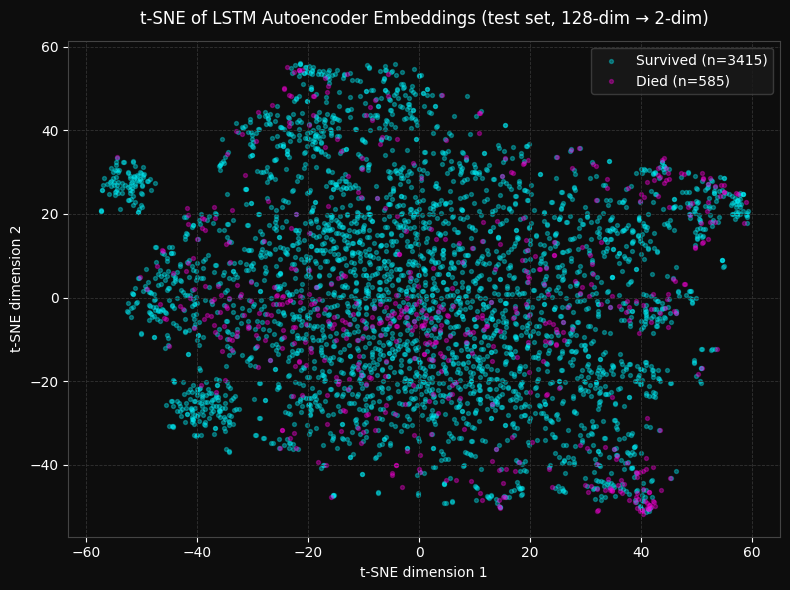

Silhouette score      (higher is better, max=1): 0.0486
Davies-Bouldin index  (lower  is better, min=0): 9.2075


In [266]:
# Use full test set embeddings (unseen during both pretraining and probe training)
z_vis  = z_test.numpy()
labels = y_test  # 0 = survived, 1 = died

# ── t-SNE ────────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
z_2d = tsne.fit_transform(z_vis)

fig, ax = styled_fig(figsize=(8, 6))
for label, color, name in zip([0, 1], NEON[:2], ['Survived', 'Died']):
    mask = labels == label
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1],
               c=color, alpha=0.35, s=8, label=f"{name} (n={mask.sum()})")

ax.set_title("t-SNE of LSTM Autoencoder Embeddings (test set, 128-dim → 2-dim)", color='white', pad=12)
ax.set_xlabel("t-SNE dimension 1", color='white')
ax.set_ylabel("t-SNE dimension 2", color='white')
style_legend(ax)
plt.tight_layout()
plt.show()

# ── Quantitative clustering metrics ──────────────────────────────────────────
# Silhouette score: ranges [-1, 1]; higher = better class separation
# Davies-Bouldin index: lower = better (ratio of within-cluster to between-cluster distances)
sil = silhouette_score(z_vis, labels, metric='euclidean', sample_size=2000, random_state=42)
db  = davies_bouldin_score(z_vis, labels)

print(f"Silhouette score      (higher is better, max=1): {sil:.4f}")
print(f"Davies-Bouldin index  (lower  is better, min=0): {db:.4f}")


### Observations

**t-SNE visualization.** The 2D projection reveals that survived and died patients are largely intermixed rather than forming clearly separated clusters. There is no distinct region in the embedding space exclusively occupied by one class. This is consistent with the pretraining objective: the MSE reconstruction loss optimizes for faithful reconstruction of all 41 ICU variables, not for separating patients by outcome. The encoder therefore captures general temporal ICU dynamics rather than mortality-discriminative structure.

**Are data points with different labels distributed identically?** Largely yes. The two classes overlap heavily in the t-SNE projection. However, there are subtle density differences in some regions, which explains why the linear probe can still achieve Test AuROC of 0.8270 on the MSE embeddings: the mortality signal is present in the embeddings, but it is entangled with other sources of variation (patient severity, ICU type, measurement patterns) that dominate the representation.

**Quantitative clustering metrics.** The Silhouette score (0.0486) is close to 0, confirming heavy class overlap with almost no cohesion or separation between survived and died patients in the embedding space. The Davies-Bouldin index (9.2075) is high, indicating that within-class scatter is large relative to between-class distance. Both metrics are consistent with the visual finding: the MSE reconstruction objective does not produce a mortality-aligned embedding space. A supervised or supervised-contrastive pretraining objective would be expected to yield a higher Silhouette score and lower Davies-Bouldin index.


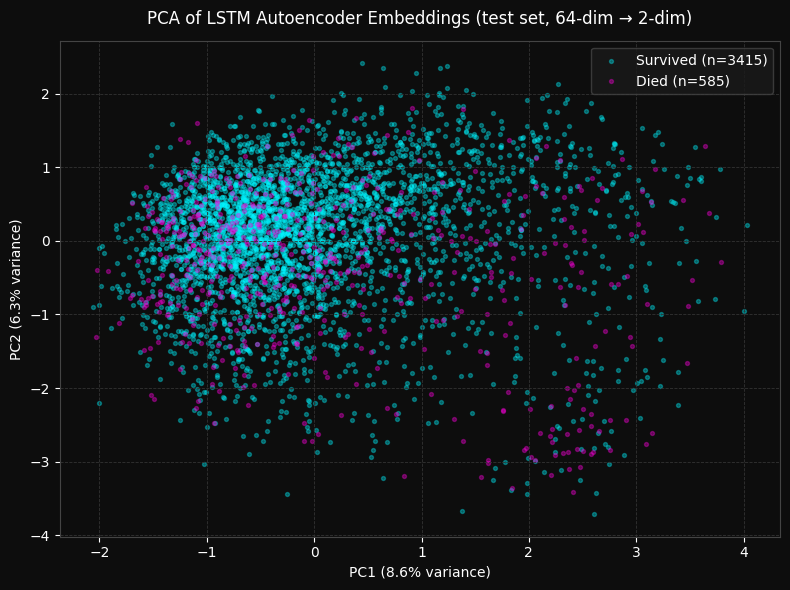

In [267]:
# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(z_vis)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = styled_fig(figsize=(8, 6))
for label, color, name in zip([0, 1], NEON[:2], ['Survived', 'Died']):
    mask = labels == label
    ax.scatter(z_pca[mask, 0], z_pca[mask, 1],
               c=color, alpha=0.35, s=8, label=f"{name} (n={mask.sum()})")

ax.set_title("PCA of LSTM Autoencoder Embeddings (test set, 64-dim → 2-dim)", color='white', pad=12)
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)", color='white')
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)", color='white')
style_legend(ax)
plt.tight_layout()
plt.show()


### PCA Observations

PCA projects the 128-dimensional embeddings onto the two directions of maximum variance. The axis labels show how much of the total variance each component captures. Together PC1 and PC2 explain only a small fraction of the total 128-dimensional variance, which already hints that the embedding space is high-dimensional and the information is spread across many directions rather than concentrated in a few.

As with t-SNE, survived and died patients are largely intermixed in the PCA projection, with no clear linear boundary separating the two classes. This is expected: PCA is a linear method and can only reveal structure that is linearly separable. Since the mortality signal in the embeddings is weak and entangled with other sources of variation (as discussed in Q3.2), neither a linear nor a non-linear projection produces clean class separation.

The PCA result complements t-SNE: t-SNE is better at revealing local non-linear cluster structure, while PCA shows the global linear structure. The fact that both show heavy class overlap consistently confirms that the MSE reconstruction objective does not produce a mortality-aligned embedding space.
